# Create drifter input files

This notebook generates text (.txt) files containing the initial positions and release times for each drifter, which are used as inputs for particle tracking.

## Imports

In [1]:
# General
import glob
import os
import numpy as np
import sys

# Data Handling
import xarray as xr
import pandas as pd

# Other
import matplotlib.pyplot as plt
import pyfesom as pf

# Custom functions
sys.path.append("/albedo/work/user/quraus001/FESOM_particles/analysis/functions/")
import FESOM_processing as fepc
import ocean_helper as ochlp
import helper as hlp


outpath = "/albedo/work/user/quraus001/FESOM_particles/input/"

/albedo/home/quraus001/pyfesom/pyfesom/climatology.py:21: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [ ]:
FESOM_depth_levels = np.array([    0.,   -10.,   -20.,   -30.,   -40.,   -50.,   -60.,   -70.,   -80.,
         -90.,  -100.,  -115.,  -135.,  -160.,  -190.,  -230.,  -280.,  -340.,
        -410.,  -490.,  -580.,  -680.,  -790.,  -910., -1040., -1180., -1330.,
       -1500., -1700., -1920., -2150., -2400., -2650., -2900., -3150., -3400.,
       -3650., -3900., -4150., -4400., -4650., -4900., -5150., -5400., -5650.,
          np.nan,    np.nan]) # These last two levels technically exist but only in the global output

## Functions

In [3]:
def write_drifter_input_df(file, df, overwrite=False):
    """
    Write a drifter input .dat file with the specified parameters.
    All input arrays must be 1D and of the same length.
    """
    if os.path.exists(file) and not overwrite:
        response = input(f"File already exists: {file}. Type 'y' to overwrite, anything else to cancel: ")
        if response.lower() != 'y':
            print("Cancelled, file not overwritten.")
            return

    with open(file, 'w') as f:
        f.write(f"{len(df)}\n")
        for _, row in df.iterrows():
            lon, lat, depth, sinking_speed, doy, year = row[:6]
            f.write(f"{lon:.2f} {lat:.2f} {depth:.1f} {sinking_speed:.1f} {doy:.0f} {year:.0f}\n")

    print(f"Wrote drifter input file: {file}")

In [4]:
def create_grid(lon_vals, lat_vals, depth_vals, sinking_speed, doy, year):
    """
    Create the Cartesian product of lon × lat × depth × doy × year.

    All of lon_vals, lat_vals, depth_vals, doy, year can be scalars or 1D arrays.
    sinking_speed can be a scalar or a 1D array broadcastable to the full size.
    """
    lon_vals   = np.atleast_1d(lon_vals)
    lat_vals   = np.atleast_1d(lat_vals)
    depth_vals = np.atleast_1d(depth_vals)
    doy_vals   = np.atleast_1d(doy)
    year_vals  = np.atleast_1d(year)

    # Build full grid: shape (len(lon), len(lat), len(depth), len(doy), len(year))
    lon_g, lat_g, depth_g, doy_g, year_g = np.meshgrid(
        lon_vals, lat_vals, depth_vals, doy_vals, year_vals, indexing="ij"
    )

    # Flatten everything
    lon_flat   = lon_g.ravel()
    lat_flat   = lat_g.ravel()
    depth_flat = depth_g.ravel()
    doy_flat   = doy_g.ravel()
    year_flat  = year_g.ravel()

    # Sinking speed: scalar → fill; array → broadcast
    n = lon_flat.size
    if np.isscalar(sinking_speed):
        sinking_speed_flat = np.full(n, sinking_speed)
    else:
        sinking_speed = np.atleast_1d(sinking_speed)
        sinking_speed_flat = np.broadcast_to(
            sinking_speed, lon_g.shape
        ).ravel()

    return lon_flat, lat_flat, depth_flat, sinking_speed_flat, doy_flat, year_flat


## Create Input

In [ ]:
dx = 5 / 60 # 5 arc minutes
lon_vals = np.arange(5, 15, dx)
doy    = 274
year   = 2006
lat    = 76
depths = FESOM_depth_levels[1:23]

lon_flat, lat_flat, depth_flat, sinking_speed_flat, doy_flat, year_flat = create_grid(lon_vals, lat, depths, sinking_speed=0, doy=doy, year=year)

df = pd.DataFrame({"lon":lon_flat, "lat":lat_flat, "depth":depth_flat*-1, "sinking_speed":sinking_speed_flat, "doy":doy_flat, "year":year_flat})
df

,lon,lat,depth,sinking_speed,doy,year
0,5.000000,76,10.0,0,274,2006
1,5.000000,76,20.0,0,274,2006
2,5.000000,76,30.0,0,274,2006
3,5.000000,76,40.0,0,274,2006
4,5.000000,76,50.0,0,274,2006
...,...,...,...,...,...,...
2635,14.916667,76,410.0,0,274,2006
2636,14.916667,76,490.0,0,274,2006
2637,14.916667,76,580.0,0,274,2006
2638,14.916667,76,680.0,0,274,2006


## different resolution at surface vs deeper levels (_not used_)

In [60]:
# different resolution at surface vs deeper levels

lon_vals_surf = np.linspace(5, 15, 1001)# 71 #np.linspace(5, 10, 21)
lon_vals_deep = np.linspace(5, 15, 401)#np.linspace(5, 10, 21)
doy = 274
year = 2006
lat = 76
depths = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 115, 135, 160, 190, 230, 280, 340] # FESOM_depth_levels[[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 17]]
depths_surf = [10, 20, 30, 40, 50] # FESOM_depth_levels[[1, 2, 3, 4, 5]]
depths_deep = [60, 70, 80, 90, 100, 115, 135, 160, 190, 230, 280, 340]# FESOM_depth_levels[[6, 7, 8, 9, 10, 12, 15, 17]]


lon_flat, lat_flat, depth_flat, sinking_speed_flat, doy_flat, year_flat = create_grid(lon_vals_surf, lat, depths_surf, sinking_speed=0, doy=doy, year=year)

df_surf = pd.DataFrame({"lon":lon_flat, "lat":lat_flat, "depth":depth_flat, "sinking_speed":sinking_speed_flat, "doy":doy_flat, "year":year_flat})

lon_flat, lat_flat, depth_flat, sinking_speed_flat, doy_flat, year_flat = create_grid(lon_vals_deep, lat, depths_deep, sinking_speed=0, doy=doy, year=year)

df_deep = pd.DataFrame({"lon":lon_flat, "lat":lat_flat, "depth":depth_flat, "sinking_speed":sinking_speed_flat, "doy":doy_flat, "year":year_flat})


df = pd.concat([df_surf, df_deep], axis=0, ignore_index=True)#.apply(pd.to_numeric)
df

,lon,lat,depth,sinking_speed,doy,year
0,5.0,76,10,0,274,2006
1,5.0,76,20,0,274,2006
2,5.0,76,30,0,274,2006
3,5.0,76,40,0,274,2006
4,5.0,76,50,0,274,2006
...,...,...,...,...,...,...
9812,15.0,76,160,0,274,2006
9813,15.0,76,190,0,274,2006
9814,15.0,76,230,0,274,2006
9815,15.0,76,280,0,274,2006


## Filtering for AW

Only keeping release positions that have Atlantic Water properties that are not yet subducted / under PW in the data frame

In [ ]:
logger = hlp.get_logger("DEBUG", "Filter watermass")

# Load FESOM mesh
meshpath = '/albedo/home/quraus001/Arc08_sub/'
mesh     = pf.load_mesh(meshpath, usepickle=True)
inpath = "/albedo/work/projects/oce_rio/cwekerle/result/Arc40/from_1988_erai/" # Path to FESOM data


all_filtered = []

for year, year_df in df.groupby("year"):
    logger.info(f"Processing year {year} ({len(year_df)} rows)")

    # Load the FESOM data for the respective year
    file = glob.glob(inpath + f"Arc40.{year}.oce.mean.sub.nc")[0]
    logger.debug(f"Loading {file}")
    ds = fepc.load_FESOM_data_with_grid(meshpath, file)

    for doy, doy_df in year_df.groupby("doy"):
        logger.debug(f"    Day-of-year {doy} ({len(doy_df)} rows before filtering)")

        # Reshape the 1D arrays (dim 3D nodes) to 2D arrays (dim (2D nodes x depth)) for the specific day
        temp = fepc.reshape_3d_nodes(ds, var="temp", time_idx=doy)
        salt = fepc.reshape_3d_nodes(ds, var="salt", time_idx=doy)
        
        doy_df = pd.DataFrame(doy_df)

        # Find the nearest 2D horizontal mesh node for each drifter's lat/lon
        nodes = []
        for lat, lon in zip(doy_df["lat"].values, doy_df["lon"].values):
            nn = pf.tunnel_fast1d(mesh.y2, mesh.x2, lat, lon)
            nodes.append(nn[0].item())

        # Find the nearest vertical depth index in the FESOM grid for each drifter
        nearest_depth_idx = np.abs(-FESOM_depth_levels[:-2, None] - doy_df["depth"].values).argmin(axis=0)

        # Extract hydrographic properties at drifter depths vs. ocean surface (index 0)
        temp_sel  = temp[nodes,nearest_depth_idx].copy()
        salt_sel  = salt[nodes,nearest_depth_idx].copy()
        temp_surf = temp[nodes,0].copy()
        salt_surf = salt[nodes,0].copy()

        # Classify water masses based on T-S criteria
        labels = ochlp.classify_water_mass(temp_sel, salt_sel, return_numeric=False)
        labels_surf = ochlp.classify_water_mass(temp_surf, salt_surf, return_numeric=False)

        # Keep only rows where water mass is AW and that are under AW surface
        mask = (labels == "AW") & (labels_surf == "AW")
        kept_count = mask.sum()
        pct_kept = (kept_count / len(mask)) * 100
        logger.info(f"      Kept {kept_count}/{len(mask)} rows ({pct_kept:.1f}% AW)")

        # Filtering
        doy_df_filtered = doy_df[mask].copy()

        # Optional: add classification as a column for reference
        doy_df_filtered["water_mass"] = labels[mask]

        # Store for later combination
        all_filtered.append(doy_df_filtered)

final_df = pd.concat(all_filtered, ignore_index=True)

logger.info(f"Final filtered DataFrame: {len(final_df)} rows total ({len(final_df)/len(df)*100:.1f}% of original)")        

/albedo/home/quraus001/Arc08_sub/pickle_mesh_py3
3
The usepickle == True)
The pickle file for python 3 exists.
The mesh will be loaded from /albedo/home/quraus001/Arc08_sub/pickle_mesh_py3
Processing year 2006 (2640 rows)
Loading /albedo/work/projects/oce_rio/cwekerle/result/Arc40/from_1988_erai/Arc40.2006.oce.mean.sub.nc
    Day-of-year 274 (2640 rows before filtering)
      Kept 1876/2640 rows (71.1% AW)
Final filtered DataFrame: 1876 rows total (71.1% of original)


### Check the last temperature sample

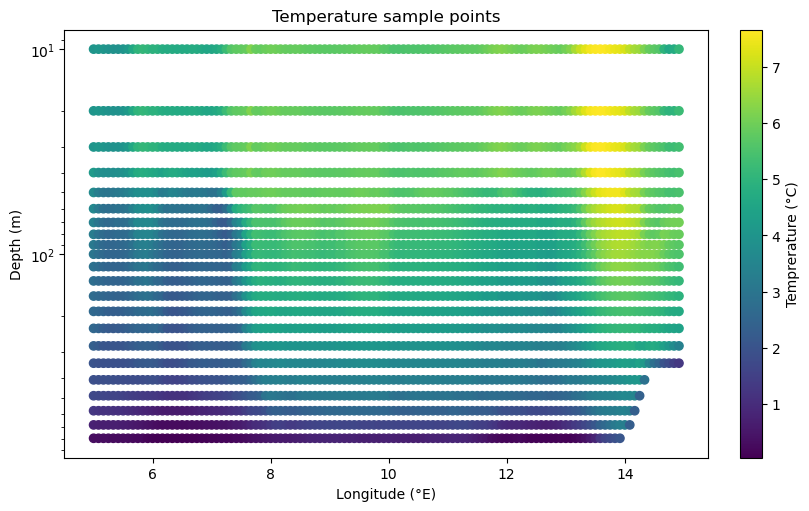

In [71]:
# Checking if the node picking worked okay
fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)
sc = ax.scatter(doy_df["lon"], doy_df["depth"], c=temp_sel)
plt.gca().set_yscale('log')
plt.gca().yaxis.set_inverted(True) 
fig.colorbar(sc, ax=ax, label="Temprerature (°C)")
ax.set_title("Temperature sample points")
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Depth (m)")
fig.show()

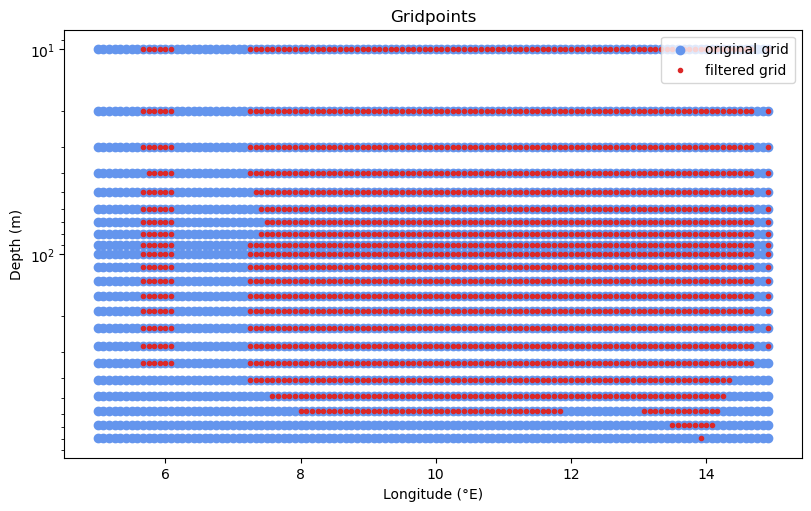

In [72]:
# Checking if the node picking worked okay
fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)
sc = ax.scatter(df["lon"], df["depth"], color="cornflowerblue", label="original grid")
ax.scatter(final_df["lon"],final_df["depth"], color="#dc2727", marker=".", label="filtered grid")

plt.gca().set_yscale('log')
plt.gca().yaxis.set_inverted(True) 

#fig.colorbar(sc, ax=ax, label="Temprerature (°C)")
ax.set_title("Gridpoints")
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Depth (m)")
ax.legend(loc="upper right")
fig.show()

### Save Output

In [48]:
final_df

,lon,lat,depth,sinking_speed,doy,year,water_mass
0,5.0,76,40.0,0,274,2006,AW
1,5.0,76,50.0,0,274,2006,AW
2,5.0,76,60.0,0,274,2006,AW
3,5.0,76,70.0,0,274,2006,AW
4,5.0,76,80.0,0,274,2006,AW
...,...,...,...,...,...,...,...
1271,15.0,76,135.0,0,274,2006,AW
1272,15.0,76,160.0,0,274,2006,AW
1273,15.0,76,190.0,0,274,2006,AW
1274,15.0,76,230.0,0,274,2006,AW


In [75]:
filename = f"drifter_input_{year}-{str(doy).zfill(3)}_lat-{lat}_particles-{len(final_df)}.dat"

write_drifter_input_df(outpath+filename, df)

Cancelled, file not overwritten.


## Get subset from existing File

In [ ]:
# This snippet is only used to rerun some trajectories and output the whole vertical column for eg. plotting
# Since the tracking code numbers trajectories always as 1, 2, ... this code also saves a mapping csv to the original full set trajectory counting

inpath = "/albedo/work/user/quraus001/FESOM_particles/input/"
to_keep = {1: [1479, 837, 1787, 957, 443, 1280, 1487, 1607, 2012, 1129, 162, 1160, 1079, 1741],
           91: [92, 319, 571],
           182: [450, 807, 1684, 982],
           274: [854, 117, 1304, 513, 815, 1008, 389]}

for doy in [1, 91, 182, 274]:
    filename = f"drifter_input_2006-{str(doy).zfill(3)}_lat-76_particles-2640.dat"

    to_keep_lst = to_keep[doy]

    df = pd.read_csv(inpath + filename, skiprows=1, names=["lon", "lat", "depth", "sinking_speed", "doy", "year"], sep=" ")


    df["drifter_idx"] = df.index
    df = df.loc[to_keep_lst].sort_index()
    # reset index to be consecutive starting from 0, but keep original drifter_idx as a column
    df.reset_index(drop=True, inplace=True)

    # Create a mapping file for the new drifter indices to the original ones
    mapping_df = pd.DataFrame({
        "new_drifter_idx": df.index,
        "original_drifter_idx": df["drifter_idx"]
    })
    mapping_df
    mapping_df.to_csv(outpath + f"drifter_idx_mapping_2006-{str(doy).zfill(3)}_subset.csv", index=False)

    # write the new subset .dat file
    new_filename = f"drifter_input_2006-{str(doy).zfill(3)}_lat-76_particles-123.dat"
    write_drifter_input_df(outpath + new_filename, df)

Cancelled, file not overwritten.
Cancelled, file not overwritten.
Cancelled, file not overwritten.
Wrote drifter input file: /albedo/work/user/quraus001/FESOM_particles/input/drifter_input_2006-274_lat-76_particles-123.dat


In [23]:
df

,lon,lat,depth,sinking_speed,doy,year,drifter_idx
0,5.75,76.0,40.0,0.0,1,2006,162
1,7.08,76.0,90.0,0.0,1,2006,443
2,9.08,76.0,40.0,0.0,1,2006,837
3,9.58,76.0,40.0,0.0,1,2006,957
4,10.08,76.0,60.0,0.0,1,2006,1079
5,10.25,76.0,280.0,0.0,1,2006,1129
6,10.42,76.0,70.0,0.0,1,2006,1160
7,10.92,76.0,70.0,0.0,1,2006,1280
8,11.75,76.0,60.0,0.0,1,2006,1479
9,11.75,76.0,190.0,0.0,1,2006,1487


In [24]:
mapping_df

,new_drifter_idx,original_drifter_idx
0,0,162
1,1,443
2,2,837
3,3,957
4,4,1079
5,5,1129
6,6,1160
7,7,1280
8,8,1479
9,9,1487
